# 1. Importing Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 2. Load the CSV Data

In [4]:
df = pd.read_csv("D:\ExcelR\Coffee Sales using Python\Coffe_sales.csv")

In [5]:
df.head()

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:50.520000
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:19:22.539000
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:20:18.089000
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,13:46:33.006000
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,13:48:14.626000


In [6]:
df.tail()

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
3542,10,card,35.76,Cappuccino,Morning,Sun,Mar,7,3,2025-03-23,10:34:54.894000
3543,14,card,35.76,Cocoa,Afternoon,Sun,Mar,7,3,2025-03-23,14:43:37.362000
3544,14,card,35.76,Cocoa,Afternoon,Sun,Mar,7,3,2025-03-23,14:44:16.864000
3545,15,card,25.96,Americano,Afternoon,Sun,Mar,7,3,2025-03-23,15:47:28.723000
3546,18,card,35.76,Latte,Night,Sun,Mar,7,3,2025-03-23,18:11:38.635000


# 3. Understanding of dataset

In [8]:
df.shape

(3547, 11)

In [9]:
df.dtypes

hour_of_day      int64
cash_type          str
money          float64
coffee_name        str
Time_of_Day        str
Weekday            str
Month_name         str
Weekdaysort      int64
Monthsort        int64
Date               str
Time               str
dtype: object

In [10]:
df.info

<bound method DataFrame.info of       hour_of_day cash_type  money    coffee_name Time_of_Day Weekday  \
0              10      card  38.70          Latte     Morning     Fri   
1              12      card  38.70  Hot Chocolate   Afternoon     Fri   
2              12      card  38.70  Hot Chocolate   Afternoon     Fri   
3              13      card  28.90      Americano   Afternoon     Fri   
4              13      card  38.70          Latte   Afternoon     Fri   
...           ...       ...    ...            ...         ...     ...   
3542           10      card  35.76     Cappuccino     Morning     Sun   
3543           14      card  35.76          Cocoa   Afternoon     Sun   
3544           14      card  35.76          Cocoa   Afternoon     Sun   
3545           15      card  25.96      Americano   Afternoon     Sun   
3546           18      card  35.76          Latte       Night     Sun   

     Month_name  Weekdaysort  Monthsort        Date             Time  
0           Mar     

In [13]:
df.describe()

,hour_of_day,money,Weekdaysort,Monthsort
count,3547.000000,3547.000000,3547.000000,3547.000000
mean,14.185791,31.645216,3.845785,6.453905
std,4.234010,4.877754,1.971501,3.500754
min,6.000000,18.120000,1.000000,1.000000
25%,10.000000,27.920000,2.000000,3.000000
50%,14.000000,32.820000,4.000000,7.000000
75%,18.000000,35.760000,6.000000,10.000000
max,22.000000,38.700000,7.000000,12.000000


# 4. Check Missing Values

In [14]:
df.isnull().sum()

hour_of_day    0
cash_type      0
money          0
coffee_name    0
Time_of_Day    0
Weekday        0
Month_name     0
Weekdaysort    0
Monthsort      0
Date           0
Time           0
dtype: int64

# 5. Check Unique Values

In [15]:
df.nunique()

hour_of_day      17
cash_type         1
money            13
coffee_name       8
Time_of_Day       3
Weekday           7
Month_name       12
Weekdaysort       7
Monthsort        12
Date            381
Time           3547
dtype: int64

# 6. Check Categorical Values

In [16]:
df["coffee_name"].value_counts()

coffee_name
Americano with Milk    809
Latte                  757
Americano              564
Cappuccino             486
Cortado                287
Hot Chocolate          276
Cocoa                  239
Espresso               129
Name: count, dtype: int64

In [17]:
df["Weekday"].value_counts()

Weekday
Tue    572
Mon    544
Fri    532
Thu    510
Wed    500
Sat    470
Sun    419
Name: count, dtype: int64

In [20]:
df["Time_of_Day"].value_counts()

Time_of_Day
Afternoon    1205
Morning      1181
Night        1161
Name: count, dtype: int64

# 7. Data Cleaning

In [6]:
df["Date"].dtype

<StringDtype(na_value=nan)>

### convert Date

In [7]:
df["Date"] = pd.to_datetime(df["Date"])

In [9]:
df["Date"].dtype

dtype('<M8[us]')

### convert Time

In [10]:
df["Time"] = pd.to_timedelta(df["Time"])

In [11]:
df["datetime"] = df["Date"] + df["Time"]

# 8. Check duplicate records

In [12]:
df.duplicated().sum()

np.int64(0)

# 9. New columns Create

### Year

In [13]:
df["Year"] = df["Date"].dt.year

### Month Number

In [14]:
df["Month"] = df["Date"].dt.month

### Day

In [15]:
df["Day"] = df["Date"].dt.day

# 10. KPI Creation

### Total Revenue

In [16]:
total_revenue = df["money"].sum()

print(total_revenue)

112245.57999999999


### Total Transactions

In [17]:
total_transactions = df.shape[0]

print(total_transactions)

3547


### Average Transaction Value

In [18]:
average_transaction = df["money"].mean()

print(average_transaction)

31.64521567521849


### Minimum Transaction

In [19]:
df["money"].min()

np.float64(18.12)

### Maximum Transaction

In [20]:
df["money"].max()

np.float64(38.7)

# 11. Created a KPI summary using NumPy

In [21]:
kpi = {
    "Total Revenue": np.sum(df["money"]),
    "Total Transactions": len(df),
    "Average Transaction": np.mean(df["money"]),
    "Median Transaction": np.median(df["money"]),
    "Minimum Transaction": np.min(df["money"]),
    "Maximum Transaction": np.max(df["money"])
}

kpi

{'Total Revenue': np.float64(112245.57999999999),
 'Total Transactions': 3547,
 'Average Transaction': np.float64(31.64521567521849),
 'Median Transaction': np.float64(32.82),
 'Minimum Transaction': np.float64(18.12),
 'Maximum Transaction': np.float64(38.7)}

# 12. Visualization

### 1. Revenue By Products

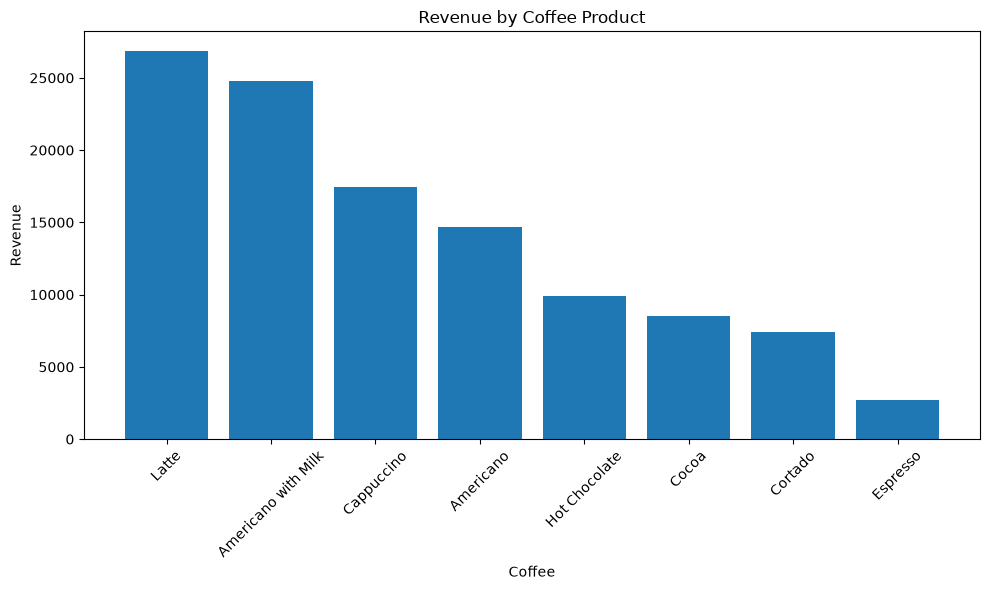

In [25]:
plt.figure(figsize=(10, 6))

plt.bar(
    coffee_sales.index,
    coffee_sales.values
)

plt.title("Revenue by Coffee Product")
plt.xlabel("Coffee")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 2. Monthly Sales

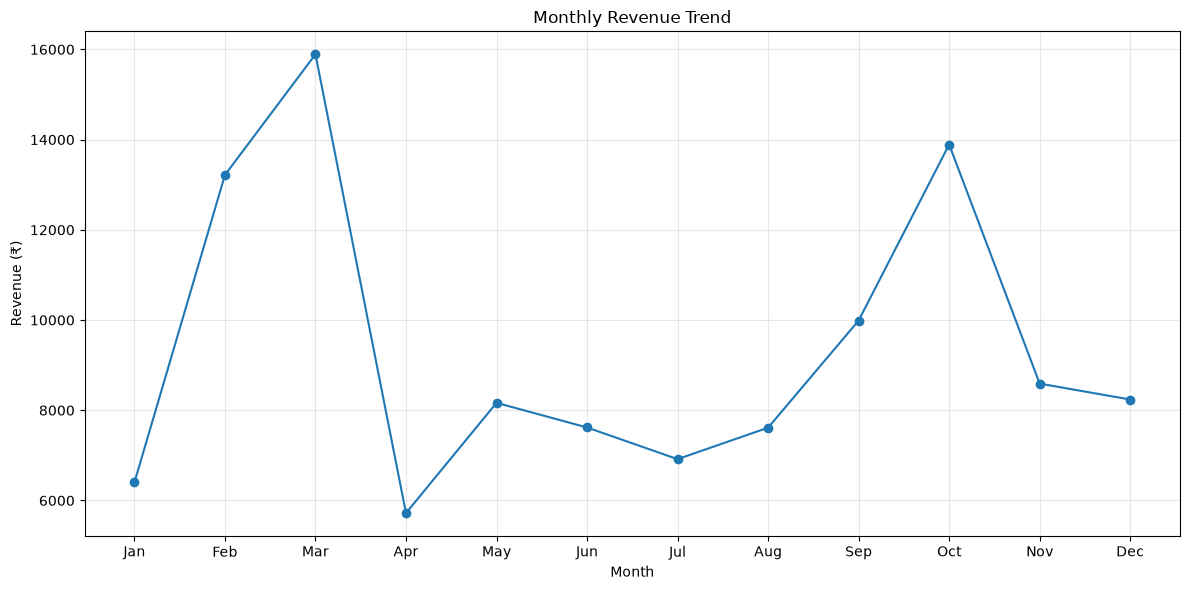

In [30]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue["Month_name"],
    monthly_revenue["money"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (₹)")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3. Transaction by hour

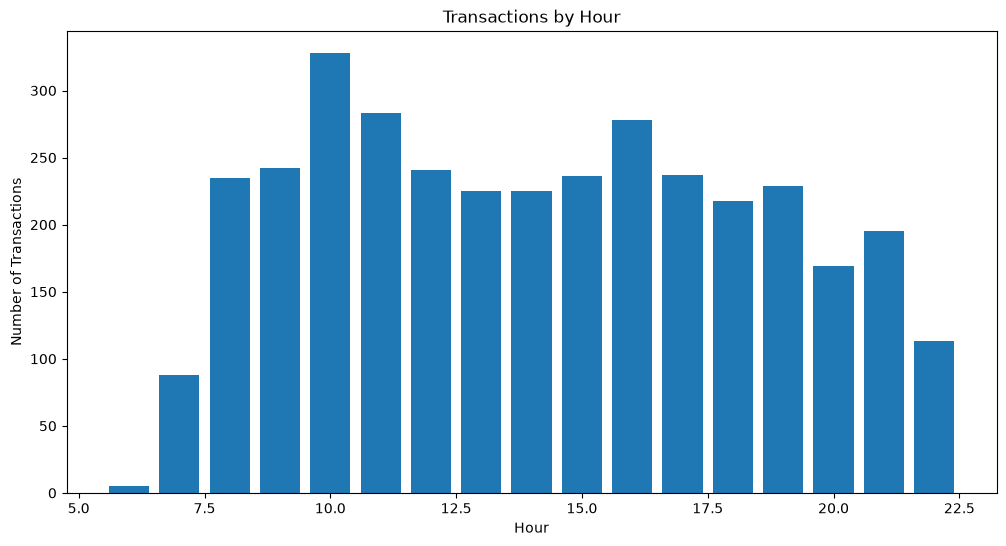

In [29]:
hourly_transactions = (
    df.groupby("hour_of_day")
      .size()
)

plt.figure(figsize=(12, 6))

plt.bar(
    hourly_transactions.index,
    hourly_transactions.values
)

plt.title("Transactions by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Transactions")

plt.show()

### 4. Weekly Sales

In [34]:
weekday_sales = (
    df.groupby(["Weekdaysort", "Weekday"])["money"]
      .sum()
      .reset_index()
      .sort_values("Weekdaysort")
)

weekday_sales

,Weekdaysort,Weekday,money
0,1,Mon,17363.10
1,2,Tue,18168.38
2,3,Wed,15750.46
3,4,Thu,16091.40
4,5,Fri,16802.66
5,6,Sat,14733.52
6,7,Sun,13336.06


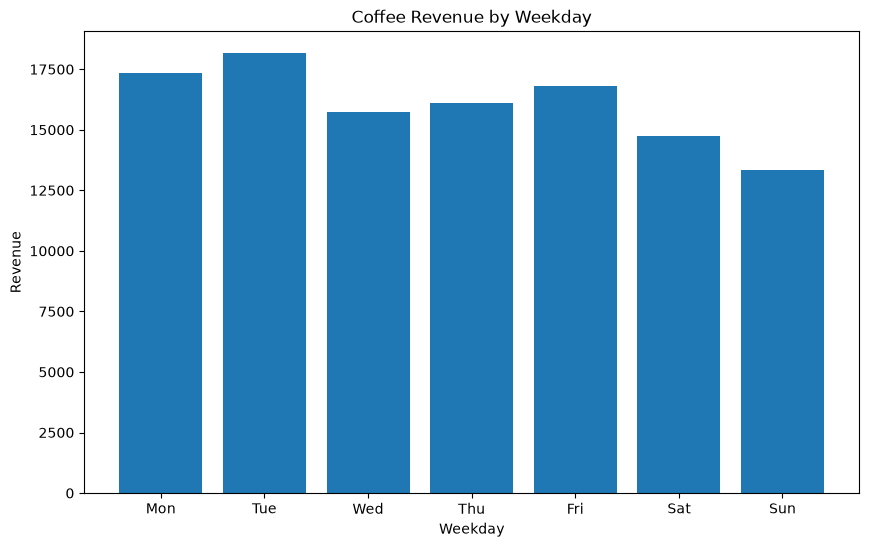

In [35]:
plt.figure(figsize=(10, 6))

plt.bar(
    weekday_sales["Weekday"],
    weekday_sales["money"]
)

plt.title("Coffee Revenue by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Revenue")

plt.show()

### 5.Revenue contribution by coffee

In [36]:
coffee_summary = (
    df.groupby("coffee_name")["money"]
      .sum()
      .sort_values(ascending=False)
)

coffee_percentage = (
    coffee_summary / coffee_summary.sum() * 100
)

print(coffee_percentage)

coffee_name
Latte                  23.943304
Americano with Milk    22.050864
Cappuccino             15.536594
Americano              13.051971
Hot Chocolate           8.849756
Cocoa                   7.591533
Cortado                 6.579199
Espresso                2.396780
Name: money, dtype: float64


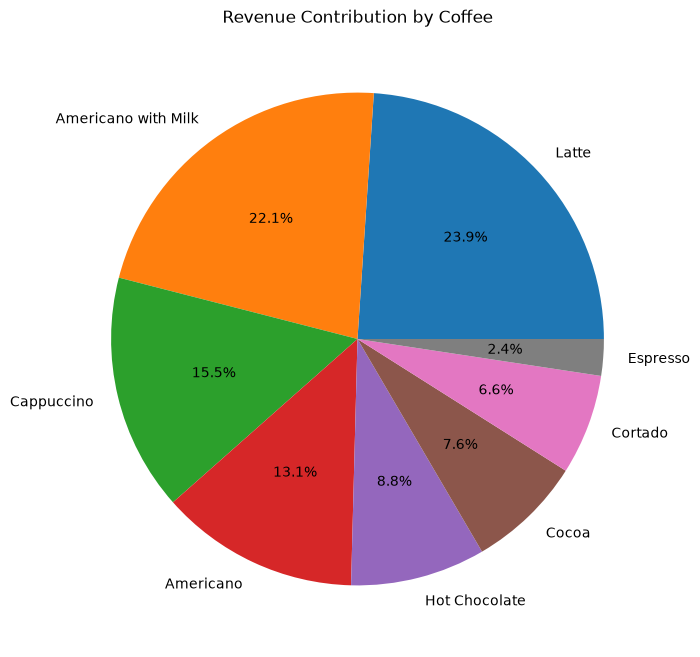

In [37]:
plt.figure(figsize=(8, 8))

plt.pie(
    coffee_summary,
    labels=coffee_summary.index,
    autopct="%1.1f%%"
)

plt.title("Revenue Contribution by Coffee")

plt.show()